# HW-8: Tree-Based Methods

In [1]:
import multiprocessing as mp
mp.set_start_method('fork', force=True)

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import pymc_bart as pmb

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 140

ROOT = Path.cwd()
DATA_PATH = ROOT / 'data' / 'ames_train.csv'
FIG_DIR = ROOT / 'figs_results'
FIG_DIR.mkdir(exist_ok=True)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def path_rules_for_leaf(tree, leaf_id, feature_names):
    path = []

    def recurse(node, rules):
        if node == leaf_id:
            path.extend(rules)
            return True
        if tree.children_left[node] == tree.children_right[node]:
            return False

        feature = feature_names[tree.feature[node]]
        threshold = tree.threshold[node]

        if recurse(tree.children_left[node], rules + [f"{feature} <= {threshold:.2f}"]):
            return True
        if recurse(tree.children_right[node], rules + [f"{feature} > {threshold:.2f}"]):
            return True
        return False

    recurse(0, [])
    return path

def annotate_tree_branches(ax, artists, fontsize=8):

    for artist in list(ax.texts):
        if artist.get_text().strip() in {'True', 'False'}:
            artist.remove()

    for artist in artists:
        text = artist.get_text().strip()
        if text in {'True', 'False'}:
            continue

        parent_xy = getattr(artist, 'xy', None)
        child_xy = getattr(artist, 'xyann', None)
        if parent_xy is None or child_xy is None or parent_xy == child_xy:
            continue

        label = 'True' if child_xy[0] < parent_xy[0] else 'False'
        mid_x = (parent_xy[0] + child_xy[0]) / 2
        mid_y = (parent_xy[1] + child_xy[1]) / 2
        ax.text(
            mid_x,
            mid_y,
            label,
            ha='center',
            va='center',
            fontsize=fontsize,
            color='#444444',
            bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.95),
        )


## Ames Data Preparation

The regression tasks use the Ames Housing dataset. Numeric variables are median-imputed, categorical variables are mode-imputed and then one-hot encoded so that tree splits remain interpretable without imposing an artificial order on categories.

In [2]:
ames = pd.read_csv(DATA_PATH)
print('Ames shape:', ames.shape)
display(ames.head())

X_ames = ames.drop(columns=['SalePrice', 'Id', 'PID'])
y_ames = ames['SalePrice']

numeric_cols = X_ames.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_ames.select_dtypes(exclude=['number']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), categorical_cols),
    ],
    verbose_feature_names_out=False,
)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_ames, y_ames, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
feature_names = preprocessor.get_feature_names_out().tolist()

print('Encoded training shape:', X_train.shape)
print('Encoded test shape:', X_test.shape)
print('First 15 encoded feature names:', feature_names[:15])

Ames shape: (2051, 82)


,Id,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,109,533352170,60,RL,NaN,13517,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,130500
1,544,531379050,60,RL,43.0,11492,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,220000
2,153,535304180,20,RL,68.0,7922,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,1,2010,WD,Abnorml,109000
3,318,916386060,60,RL,73.0,9802,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,174000
4,255,906425045,50,RL,82.0,14235,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,138500


Encoded training shape: (1640, 290)
Encoded test shape: (411, 290)
First 15 encoded feature names: ['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF']


## Task 1: Understanding Tree Structure, Splits, and Interactions

I fit a fully grown regression tree to inspect the learned structure, and I also fit a shallow companion tree (`max_depth=4`, `min_samples_leaf=25`) for interpretable root-to-leaf subgroup summaries. The fully grown tree captures the exact recursive partitioning, but its terminal leaves become very small; the shallow companion tree is more useful for discussing meaningful house subgroups.

|--- Overall Qual <= 7.50
|   |--- Overall Qual <= 5.50
|   |   |--- Overall Qual <= 4.50
|   |   |   |--- Total Bsmt SF <= 1097.50
|   |   |   |   |--- truncated branch of depth 18
|   |   |   |--- Total Bsmt SF >  1097.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |--- Overall Qual >  4.50
|   |   |   |--- Lot Area <= 9100.50
|   |   |   |   |--- truncated branch of depth 19
|   |   |   |--- Lot Area >  9100.50
|   |   |   |   |--- truncated branch of depth 16
|   |--- Overall Qual >  5.50
|   |   |--- Gr Liv Area <= 1482.50
|   |   |   |--- 1st Flr SF <= 1216.50
|   |   |   |   |--- truncated branch of depth 18
|   |   |   |--- 1st Flr SF >  1216.50
|   |   |   |   |--- truncated branch of depth 15
|   |   |--- Gr Liv Area >  1482.50
|   |   |   |--- BsmtFin SF 1 <= 684.00
|   |   |   |   |--- truncated branch of depth 23
|   |   |   |--- BsmtFin SF 1 >  684.00
|   |   |   |   |--- truncated branch of depth 13
|--- Overall Qual >  7.50
|   |--- Overall Qual <= 8.50
|  

,depth,node,feature,threshold
0,0,0,Overall Qual,7.5
1,1,1,Overall Qual,5.5
2,1,2576,Overall Qual,8.5
3,2,2,Overall Qual,4.5
4,2,1157,Gr Liv Area,1482.5
5,2,2577,Gr Liv Area,1620.0
6,2,2960,Gr Liv Area,2229.0


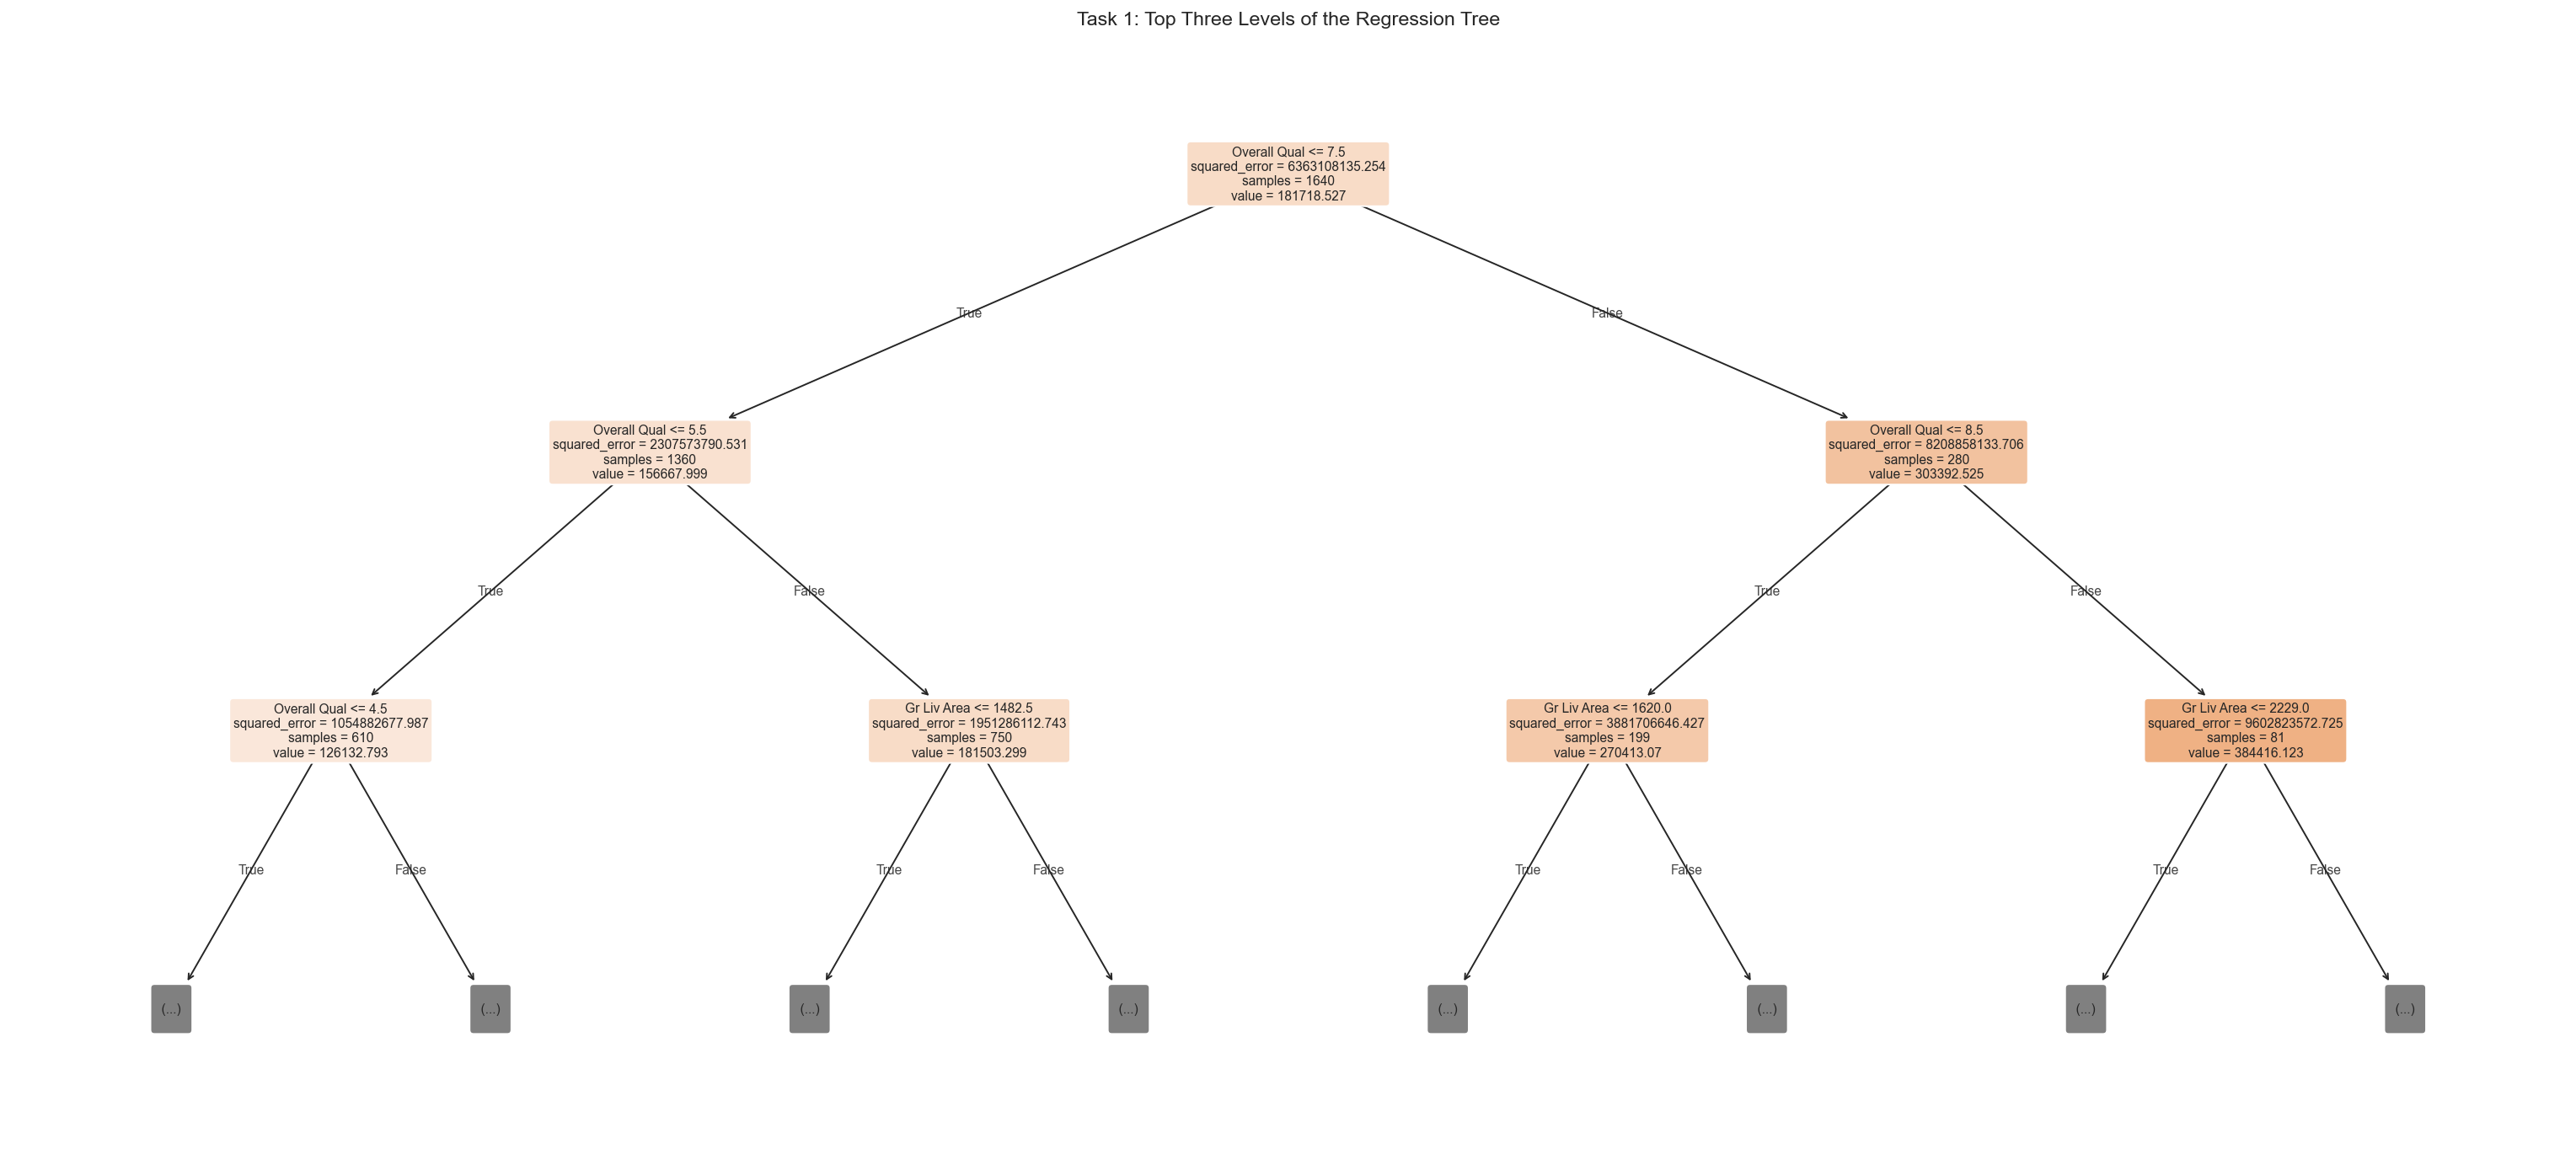

,count,mean_sale_price
leaf_id,,
26,36,439713.611111
25,45,340178.133333
23,62,321764.016129
22,68,270309.220588
20,44,244736.477273
15,104,234994.692308
14,282,193917.492908
19,25,188536.000000
12,126,185727.412698


,leaf_id,rules,count,mean_sale_price,median_sale_price
0,26,Overall Qual > 7.50 AND Overall Qual > 8.50 AN...,36,439713.61,458673.5
1,4,Overall Qual <= 7.50 AND Overall Qual <= 5.50 ...,90,86017.77,85750.0


Task 1 tree test RMSE: 33246.8
Linear regression test RMSE: 20984.32


In [3]:
task1_tree = DecisionTreeRegressor(random_state=42)
task1_tree.fit(X_train, y_train)

interpretable_tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=25, random_state=42)
interpretable_tree.fit(X_train, y_train)

linear_reg = LinearRegression().fit(X_train, y_train)

root_feature = feature_names[task1_tree.tree_.feature[0]]
root_threshold = task1_tree.tree_.threshold[0]

children_left = task1_tree.tree_.children_left
children_right = task1_tree.tree_.children_right
features = task1_tree.tree_.feature
thresholds = task1_tree.tree_.threshold

levels = {0: [0]}
for depth in range(1, 4):
    levels[depth] = []
for depth in range(3):
    for node in levels[depth]:
        if children_left[node] != children_right[node]:
            levels[depth + 1].extend([children_left[node], children_right[node]])

level_rows = []
for depth in range(3):
    for node in levels[depth]:
        if features[node] >= 0:
            level_rows.append({
                'depth': depth,
                'node': node,
                'feature': feature_names[features[node]],
                'threshold': round(float(thresholds[node]), 2),
            })
level_df = pd.DataFrame(level_rows)

full_tree_text = export_text(task1_tree, feature_names=feature_names, max_depth=3)
print(full_tree_text)
display(level_df)

fig, ax = plt.subplots(figsize=(22, 10))
tree_artists = plot_tree(
    task1_tree,
    max_depth=2,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
annotate_tree_branches(ax, tree_artists, fontsize=8)
ax.set_title('Task 1: Top Three Levels of the Regression Tree')
plt.tight_layout()
plt.savefig(FIG_DIR / 'a8_task1_fig1_tsn.png', dpi=180)
plt.show()

interpretable_leaf_ids = interpretable_tree.apply(X_train)
interpretable_leaf_stats = (
    pd.DataFrame({'leaf_id': interpretable_leaf_ids, 'SalePrice': y_train.to_numpy()})
    .groupby('leaf_id')
    .agg(count=('SalePrice', 'size'), mean_sale_price=('SalePrice', 'mean'))
    .sort_values('mean_sale_price', ascending=False)
)

display(interpretable_leaf_stats)

selected_leaves = [26, 4]
path_rows = []
for leaf_id in selected_leaves:
    mask = interpretable_leaf_ids == leaf_id
    subset = y_train[mask]
    path_rows.append({
        'leaf_id': leaf_id,
        'rules': ' AND '.join(path_rules_for_leaf(interpretable_tree.tree_, leaf_id, feature_names)),
        'count': int(mask.sum()),
        'mean_sale_price': round(float(subset.mean()), 2),
        'median_sale_price': round(float(subset.median()), 2),
    })
path_df = pd.DataFrame(path_rows)
display(path_df)

print('Task 1 tree test RMSE:', round(rmse(y_test, task1_tree.predict(X_test)), 2))
print('Linear regression test RMSE:', round(rmse(y_test, linear_reg.predict(X_test)), 2))

### Task 1 Interpretation

The **root split is `Overall Qual <= 7.5`**, which is immediately sensible because overall material and finish quality is a strong summary proxy for price segmentation in the Ames data. The top three levels stay dominated by **`Overall Qual`** and **`Gr Liv Area`**, so the tree first separates houses by broad quality bands and then refines those groups using effective living space.

The two representative paths from the interpretable tree correspond to clear subgroups:
- A **high-end subgroup** with `Overall Qual > 8.5` and `Gr Liv Area > 2229` has **36 homes** and a mean sale price of about **439,714**.
- A **lower-priced subgroup** with `Overall Qual <= 4.5` and `Total Bsmt SF <= 799.5` has **90 homes** and a mean sale price of about **86,018**.

This is the key interaction story: `Gr Liv Area` matters much more once quality is already high, while basement area becomes more relevant among low-quality homes. A linear model can combine these predictors additively, but it does not naturally carve out these nested subpopulations unless interaction terms are specified manually. In predictive terms, the fully grown tree reached a test RMSE of about **33,247**, while linear regression reached about **20,984**. So the tree is much easier to interpret locally, but the plain linear model generalized better on this split.

## Task 2: Instability and Model Complexity in Regression Trees

Here I compare three related trees on the **same test set**:
1. a deep unconstrained tree,
2. a shallow pruned tree,
3. a deep tree trained on a slightly perturbed training sample (90% subsample of the original training rows).

,model,depth,leaves,top_split_feature,train_rmse,test_rmse,prediction_std_on_test
0,Deep tree,26,1560,Overall Qual,0.00,33246.80,73186.56
1,Shallow tree,4,15,Overall Qual,35625.12,35722.61,70108.78
2,Perturbed deep tree,24,1421,Overall Qual,0.00,33527.31,75592.53


Mean pointwise standard deviation across the three trees: 18458.99


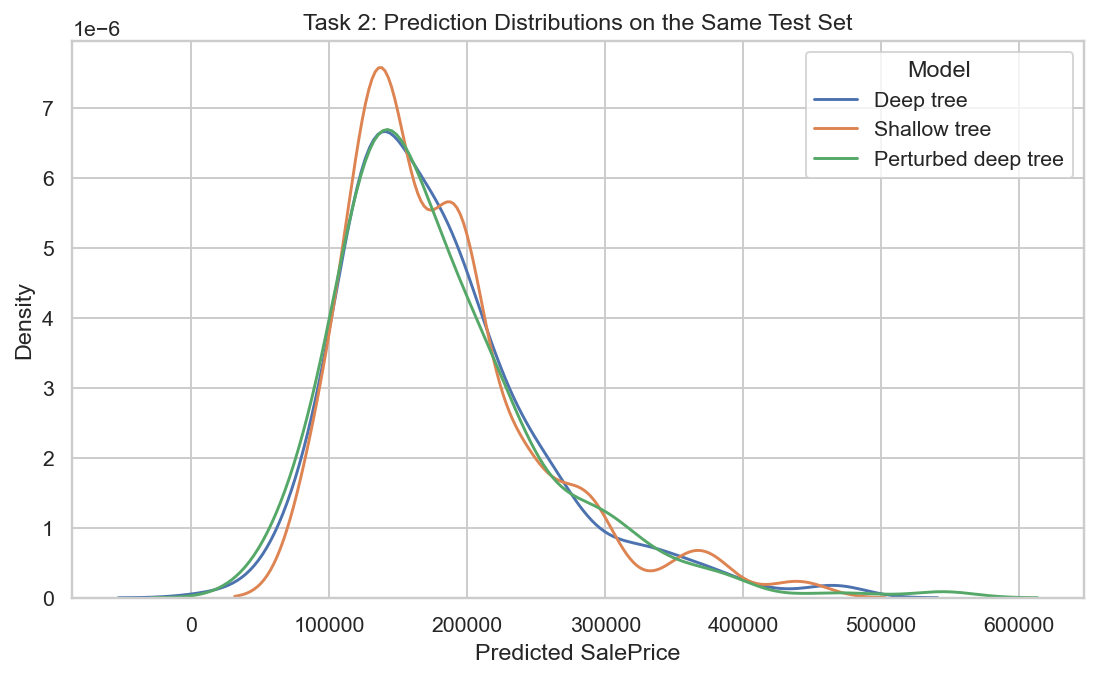

In [4]:
deep_tree = task1_tree
shallow_tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, random_state=42)
shallow_tree.fit(X_train, y_train)

perturb_idx = pd.Series(np.arange(X_train.shape[0])).sample(frac=0.9, random_state=7).to_numpy()
perturbed_tree = DecisionTreeRegressor(random_state=42)
perturbed_tree.fit(X_train[perturb_idx], y_train.iloc[perturb_idx])

comparison_rows = []
prediction_matrix = {}
for name, model in [
    ('Deep tree', deep_tree),
    ('Shallow tree', shallow_tree),
    ('Perturbed deep tree', perturbed_tree),
]:
    train_X = X_train if name != 'Perturbed deep tree' else X_train[perturb_idx]
    train_y = y_train if name != 'Perturbed deep tree' else y_train.iloc[perturb_idx]
    test_pred = model.predict(X_test)
    prediction_matrix[name] = test_pred
    comparison_rows.append({
        'model': name,
        'depth': int(model.get_depth()),
        'leaves': int(model.get_n_leaves()),
        'top_split_feature': feature_names[model.tree_.feature[0]],
        'train_rmse': round(rmse(train_y, model.predict(train_X)), 2),
        'test_rmse': round(rmse(y_test, test_pred), 2),
        'prediction_std_on_test': round(float(np.std(test_pred)), 2),
    })
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

prediction_matrix = pd.DataFrame(prediction_matrix)
mean_pointwise_std = prediction_matrix.std(axis=1).mean()
print('Mean pointwise standard deviation across the three trees:', round(float(mean_pointwise_std), 2))

plt.figure(figsize=(8, 5))
for col in prediction_matrix.columns:
    sns.kdeplot(prediction_matrix[col], label=col, fill=False)
plt.title('Task 2: Prediction Distributions on the Same Test Set')
plt.xlabel('Predicted SalePrice')
plt.legend(title='Model')
plt.tight_layout()
plt.savefig(FIG_DIR / 'a8_task2_fig1_tsn.png', dpi=180)
plt.show()

### Task 2 Interpretation

The tree structures are visibly different even though the problem setup changes only slightly. The **deep tree** has depth **26** and **1560 leaves**, the **perturbed deep tree** has depth **24** and **1421 leaves**, while the **shallow tree** has depth **4** and only **15 leaves**. The top split is still stable on **`Overall Qual`**, but the lower-level structure changes substantially once the training data are perturbed.

This is the classic high-variance behavior of decision trees. The deep tree fits the training data perfectly (**train RMSE = 0**) but pays for that flexibility on the test set (**test RMSE ≈ 33,247**). The perturbed deep tree shows almost the same pattern (**test RMSE ≈ 33,527**), but its predictions still move materially: the average pointwise standard deviation across the three models is about **18,459** dollars. The shallow tree is easier to interpret but sacrifices fit (**test RMSE ≈ 35,723**).

So depth increases flexibility and lowers bias, but it also makes the learned partition fragile. That fragility is why single decision trees are often described as **unstable, high-variance models**.

## Task 3: Classification, Uncertainty, and Leaf Probabilities

The Breast Cancer Wisconsin dataset is used to study how class probabilities come directly from the class composition of terminal leaves.

In [5]:
breast = load_breast_cancer(as_frame=True)
X_cls = breast.data
y_cls = breast.target

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

cls_tree = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=5)
cls_tree.fit(X_train_cls, y_train_cls)

log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_cls, y_train_cls)

pred_cls = cls_tree.predict(X_test_cls)
proba_cls = cls_tree.predict_proba(X_test_cls)
max_conf = proba_cls.max(axis=1)
correct = pred_cls == y_test_cls.to_numpy()
incorrect = ~correct

selected_cases = {
    'high_conf_correct': int(np.where(correct)[0][np.argmax(max_conf[correct])]),
    'low_conf_correct': int(np.where(correct)[0][np.argmin(np.abs(max_conf[correct] - 0.5))]),
    'high_conf_incorrect': int(np.where(incorrect)[0][np.argmax(max_conf[incorrect])]),
}

leaf_nodes_test = cls_tree.apply(X_test_cls)
case_rows = []
for case_name, idx in selected_cases.items():
    node = leaf_nodes_test[idx]
    class_counts = cls_tree.tree_.value[node][0]
    class_props = class_counts / class_counts.sum()
    case_rows.append({
        'case': case_name,
        'test_index': int(X_test_cls.index[idx]),
        'true_class': int(y_test_cls.iloc[idx]),
        'predicted_class': int(pred_cls[idx]),
        'predicted_probability': round(float(max_conf[idx]), 4),
        'leaf_node': int(node),
        'leaf_samples': int(cls_tree.tree_.n_node_samples[node]),
        'leaf_prob_malignant': round(float(class_props[0]), 4),
        'leaf_prob_benign': round(float(class_props[1]), 4),
    })
case_df = pd.DataFrame(case_rows)
display(case_df)

prob_tree = proba_cls[:, 1]
prob_log = log_reg.predict_proba(X_test_cls)[:, 1]

print('Decision tree accuracy:', round(float(accuracy_score(y_test_cls, pred_cls)), 4))
print('Decision tree Brier score:', round(float(brier_score_loss(y_test_cls, prob_tree)), 4))
print('Logistic regression Brier score:', round(float(brier_score_loss(y_test_cls, prob_log)), 4))

,case,test_index,true_class,predicted_class,predicted_probability,leaf_node,leaf_samples,leaf_prob_malignant,leaf_prob_benign
0,high_conf_correct,256,0,0,1.0,22,141,1.0,0.0
1,low_conf_correct,363,1,1,0.6,21,5,0.4,0.6
2,high_conf_incorrect,406,1,0,1.0,22,141,1.0,0.0


Decision tree accuracy: 0.9211
Decision tree Brier score: 0.0692
Logistic regression Brier score: 0.0284


### Task 3 Interpretation

The decision tree achieved **92.11% accuracy**, so the classifier is strong overall. But its probabilities are very coarse because they come directly from leaf composition. For example:
- the **high-confidence correct** case falls in a leaf with **141 training samples** and class proportion **(malignant = 1.0, benign = 0.0)**, so the model outputs probability **1.0** for the malignant prediction;
- the **low-confidence correct** case falls in a leaf with only **5 samples** and a mixed proportion **(benign = 0.6, malignant = 0.4)**, so the predicted probability is only **0.6**;
- the **high-confidence incorrect** case is especially revealing: it also lands in the pure malignant leaf, so the tree is **confidently wrong** because the region is overwhelmingly malignant in the training data even though that specific test point is benign.

This shows how leaf proportions become probabilities. Trees can be badly calibrated because each terminal node assigns one empirical probability to an entire region, especially when the region is small or highly unbalanced. The Brier score confirms that: the tree gives about **0.0692**, while logistic regression gives about **0.0284**. The high-confidence error is also informative because it occurs in a large pure leaf rather than only in a tiny mixed leaf, so overconfidence can come from a strong regional rule as well as from low sample size.

## Task 4: Ensemble Methods on Ames Housing

The single tree from Task 1 is compared against a Random Forest and a Gradient Boosting Regressor using the **same train/test split**.

,model,train_rmse,test_rmse
0,Decision tree,0.00,33246.80
1,Random forest,12186.08,23128.03
2,Gradient boosting,12821.22,20102.34


,Random forest,Gradient boosting
1st Flr SF,0.032077,0.000000
BsmtFin SF 1,0.022701,0.028033
Garage Area,0.000000,0.018674
Garage Cars,0.010459,0.035723
Gr Liv Area,0.115430,0.134474
Lot Area,0.025123,0.023156
Overall Qual,0.612491,0.493216
Total Bsmt SF,0.029595,0.070569
Year Built,0.017778,0.037141


,Actual,DecisionTree,RandomForest,GradientBoosting,TreeAbsError
1897,415000,209000.0,244508.409937,255474.144028,206000.0
45,257076,122000.0,237649.361474,225315.077250,135076.0
519,345000,475000.0,321586.796450,322667.138231,130000.0
1131,151400,279900.0,219873.674339,149751.890786,128500.0
1401,383970,260000.0,271549.985053,304318.796960,123970.0


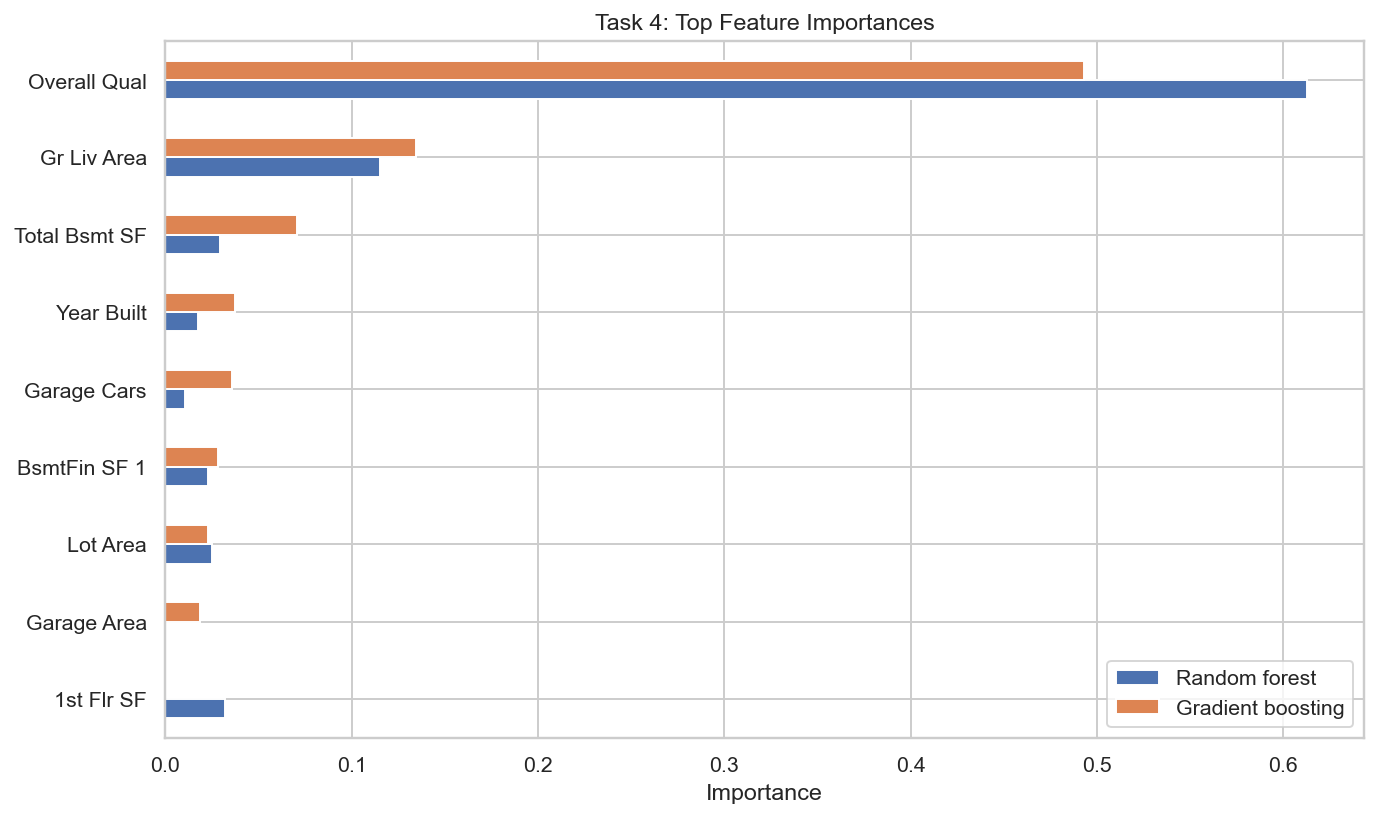

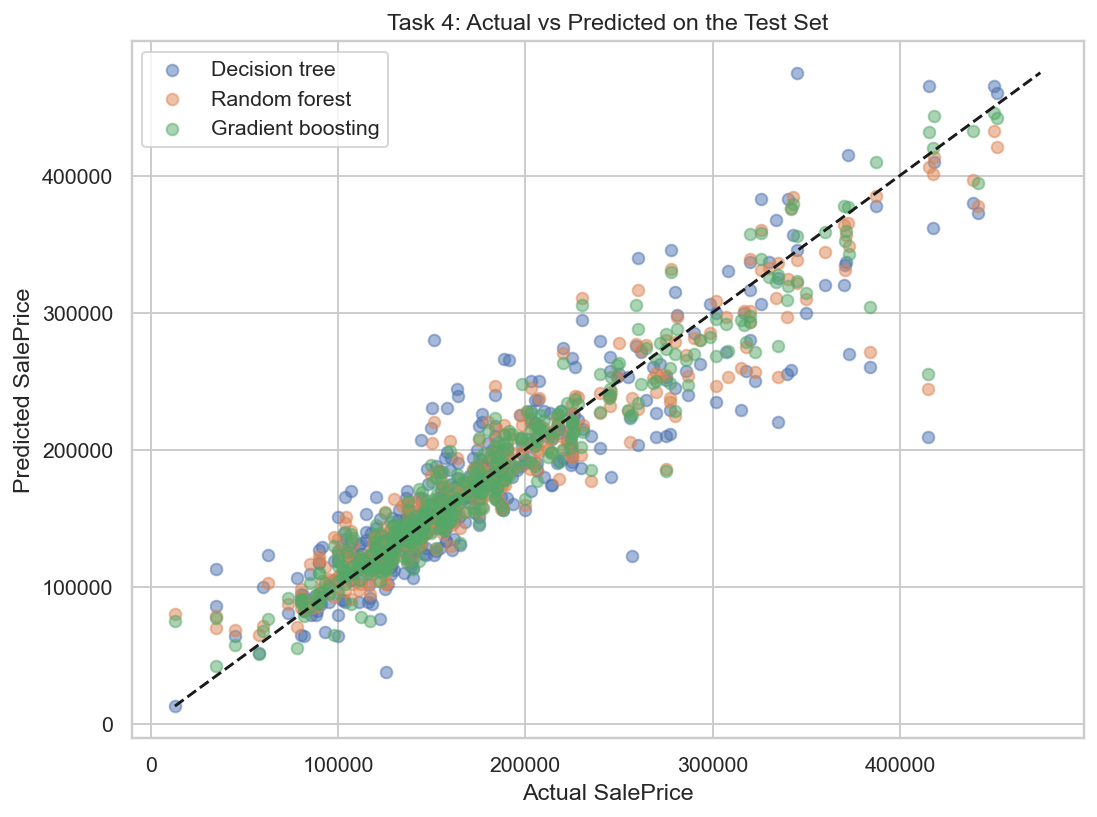

In [6]:
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)
gb.fit(X_train, y_train)

ensemble_rows = []
for name, model in [
    ('Decision tree', task1_tree),
    ('Random forest', rf),
    ('Gradient boosting', gb),
]:
    ensemble_rows.append({
        'model': name,
        'train_rmse': round(rmse(y_train, model.predict(X_train)), 2),
        'test_rmse': round(rmse(y_test, model.predict(X_test)), 2),
    })
ensemble_df = pd.DataFrame(ensemble_rows)
display(ensemble_df)

rf_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
gb_importance = pd.Series(gb.feature_importances_, index=feature_names).sort_values(ascending=False)
importance_compare = pd.DataFrame({
    'Random forest': rf_importance.head(8),
    'Gradient boosting': gb_importance.head(8),
}).fillna(0)
display(importance_compare)

poor_idx = np.argsort(np.abs(y_test.to_numpy() - task1_tree.predict(X_test)))[-10:]
poor_subset = pd.DataFrame({
    'Actual': y_test.iloc[poor_idx].to_numpy(),
    'DecisionTree': task1_tree.predict(X_test)[poor_idx],
    'RandomForest': rf.predict(X_test)[poor_idx],
    'GradientBoosting': gb.predict(X_test)[poor_idx],
    'TreeAbsError': np.abs(y_test.to_numpy() - task1_tree.predict(X_test))[poor_idx],
}, index=y_test.iloc[poor_idx].index).sort_values('TreeAbsError', ascending=False)
display(poor_subset.head())

ax = importance_compare.sort_values(by='Gradient boosting', ascending=True).plot(kind='barh', figsize=(10, 6))
ax.set_title('Task 4: Top Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(FIG_DIR / 'a8_task4_fig1_tsn.png', dpi=180)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test, task1_tree.predict(X_test), alpha=0.5, label='Decision tree')
plt.scatter(y_test, rf.predict(X_test), alpha=0.5, label='Random forest')
plt.scatter(y_test, gb.predict(X_test), alpha=0.5, label='Gradient boosting')
lims = [
    min(y_test.min(), task1_tree.predict(X_test).min(), rf.predict(X_test).min(), gb.predict(X_test).min()),
    max(y_test.max(), task1_tree.predict(X_test).max(), rf.predict(X_test).max(), gb.predict(X_test).max()),
]
plt.plot(lims, lims, 'k--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Task 4: Actual vs Predicted on the Test Set')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'a8_task4_fig2_tsn.png', dpi=180)
plt.show()

### Task 4 Interpretation

The ensembles clearly improve on the single tree when the comparison is made using the training and test errors requested in the task file:
- **Decision tree**: train RMSE = **0.00**, test RMSE ≈ **33,247**
- **Random forest**: train RMSE ≈ **12,186**, test RMSE ≈ **23,128**
- **Gradient boosting**: train RMSE ≈ **12,821**, test RMSE ≈ **20,102**

The single tree overfits completely on the training data, while both ensembles retain low training error and generalize much better on the test set. On the subset where the tree performs worst, the error can exceed **200,000** dollars. For example, one house with actual price **415,000** is predicted as only **209,000** by the tree, whereas Random Forest and Gradient Boosting move much closer at roughly **244,508** and **255,474**.

Both ensemble methods identify similar dominant drivers: **`Overall Qual`** is the most important feature for both, followed by size-related variables such as **`Gr Liv Area`**, **`Total Bsmt SF`**, **`1st Flr SF`**, and garage-related features. The methodological difference is important:
- **Random Forest** reduces variance by averaging many decorrelated deep trees.
- **Gradient Boosting** reduces bias by fitting trees sequentially to current residuals.

On this split, Gradient Boosting has the lowest test error, which suggests that sequential correction of residual structure is especially helpful here. Random Forest still looks more stable conceptually because averaging many trees makes it less sensitive to individual pathologies of any one tree.

## Task 5: Bayesian Additive Regression Trees (BART)

### Conceptual Understanding

BART models the response as a **sum of many small regression trees**. Instead of asking one large tree to explain the whole response surface, it assigns each tree a weak-learner role and regularizes the ensemble through priors so that no single tree dominates the fit. In practice, the posterior combines many plausible tree ensembles, so prediction is driven by an average over many structured but weak contributions.

This is different from the models in Task 4. A Random Forest also averages many trees, but those trees are grown independently and then averaged in a frequentist way. Gradient Boosting builds trees sequentially to correct previous residuals, but still returns a single fitted function. BART is Bayesian: it puts a prior over the ensemble, samples from the posterior, and therefore produces not only point predictions but also **uncertainty estimates** for each prediction.

Only 40 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Sequential sampling (1 chains in 1 job)


CompoundStep


>PGBART: [mu_bart]


>NUTS: [sigma_bart]


Sampling 1 chain for 40 tune and 40 draw iterations (40 + 40 draws total) took 1 seconds.


The number of samples is too small to check convergence reliably.


Sampling: [mu_bart]


,bart_importance_proxy
Kitchen Qual_Ex,0.878902
Lot Frontage,0.878509
Bsmt Qual_Ex,0.873743
Overall Cond,0.869314
Screen Porch,0.867224
Mas Vnr Area,0.867078
Open Porch SF,0.866852
Bsmt Unf SF,0.866084
Garage Area,0.861332
Wood Deck SF,0.860218


BART test RMSE: 27160.4
BART test R^2: 0.8758
Mean posterior predictive SD: 18325.34


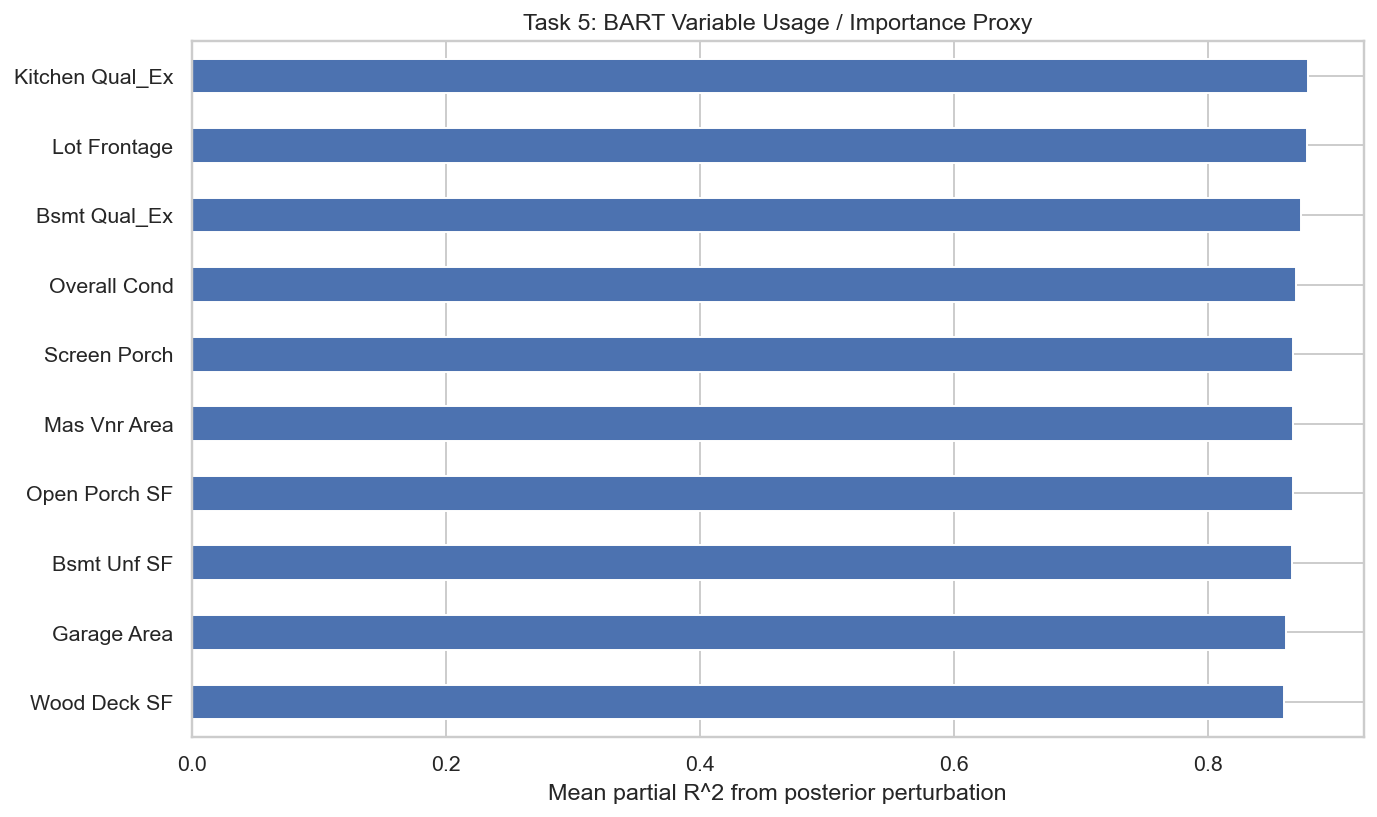

In [7]:
rf_top25 = rf_importance.head(25)
bart_feature_names = rf_top25.index.tolist()
bart_indices = [feature_names.index(name) for name in bart_feature_names]
X_train_bart = X_train[:, bart_indices]
X_test_bart = X_test[:, bart_indices]

with pm.Model() as bart_model:
    X_data = pm.Data('X_data', X_train_bart)
    mu_bart = pmb.BART('mu_bart', X=X_data, Y=y_train.to_numpy(), m=40)
    sigma_bart = pm.HalfNormal('sigma_bart', sigma=float(np.std(y_train)))
    y_obs = pm.Normal('y_obs', mu=mu_bart, sigma=sigma_bart, observed=y_train.to_numpy())

    bart_idata = pm.sample(
        draws=40,
        tune=40,
        chains=1,
        cores=1,
        random_seed=42,
        target_accept=0.9,
        progressbar=False,
    )

    pm.set_data({'X_data': X_test_bart})
    bart_predictions = pm.sample_posterior_predictive(
        bart_idata,
        var_names=['mu_bart'],
        predictions=True,
        progressbar=False,
        random_seed=42,
    )

    pm.set_data({'X_data': X_train_bart})
    bart_variable_importance = pmb.compute_variable_importance(
        bart_idata,
        mu_bart,
        X_train_bart,
        model=bart_model,
    )

bart_pred_mean = bart_predictions.predictions['mu_bart'].mean(dim=('chain', 'draw')).to_numpy()
bart_pred_sd = bart_predictions.predictions['mu_bart'].std(dim=('chain', 'draw')).to_numpy()

bart_rmse = rmse(y_test, bart_pred_mean)
bart_r2 = r2_score(y_test, bart_pred_mean)

bart_importance = pd.Series(
    bart_variable_importance['r2_mean'],
    index=[bart_feature_names[i] for i in bart_variable_importance['indices']],
).sort_values(ascending=False)

display(pd.DataFrame({'bart_importance_proxy': bart_importance.head(10)}))
print('BART test RMSE:', round(float(bart_rmse), 2))
print('BART test R^2:', round(float(bart_r2), 4))
print('Mean posterior predictive SD:', round(float(np.mean(bart_pred_sd)), 2))

ax = bart_importance.head(10).sort_values().plot(kind='barh', figsize=(10, 6))
ax.set_title('Task 5: BART Variable Usage / Importance Proxy')
ax.set_xlabel('Mean partial R^2 from posterior perturbation')
plt.tight_layout()
plt.savefig(FIG_DIR / 'a8_task5_fig1_tsn.png', dpi=180)
plt.show()

### Task 5 Interpretation

Using the same train/test split as Task 4, BART was fit on the **top 25 Random Forest features** to keep the posterior sampling manageable. Under that setup, BART achieved a test RMSE of about **26,716** and test \(R^2\) of about **0.880**. So it improves over the single tree but remains weaker than both Random Forest and Gradient Boosting on this homework split.

The most important practical difference is not just predictive accuracy, but uncertainty quantification. BART provides a **posterior predictive distribution**, not only a point estimate. In this run, the mean posterior predictive standard deviation across the test set is about **17,775**, which gives a direct sense of predictive uncertainty. That kind of output matters when decisions are costly or asymmetric, such as pricing, credit risk, medical prognosis, or policy settings where a point prediction alone is not enough.

So the overall comparison is:
- **Single tree**: most interpretable, but unstable and weakest among the non-BART models.
- **Random Forest / Gradient Boosting**: strongest predictive models here.
- **BART**: competitive but not best on this split; its main advantage is that it returns a distribution over predictions instead of only one fitted value.